# 2025/10/07 - Kraken2 profiling

In [80]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from seaborn import objects as so
import tqdm
import taxoniq
from scipy.stats import f_oneway
from scipy.stats import kruskal
plt.rcParams['svg.fonttype'] = 'none'

habitat_palette = {
    "Crop": "#0CAB7B", 
    "Edge": "#3A8DFA", 
    "Oak": "#FB2231",
    "Wasteland": "#FFC51F"
}

In [81]:
with open('../results/2025-10-07.kraken2-pfp16-run-high/.input') as f:
    index = list(map(lambda x: x.strip(), f.readlines()))

In [82]:
hits = []
counts = []
for file in tqdm.tqdm(index):
    hits_tmp = pd.read_csv(f'../results/2025-10-07.kraken2-pfp16-run-high/{file}.taxonomy.tsv', index_col=0)
    hits.append(hits_tmp)
    
hits = pd.concat(hits).reset_index()
# hits['library'] = hits['library'].apply(lambda x: x)
hits

100%|██████████| 322/322 [00:00<00:00, 726.79it/s]


,library,classification-ratio,taxonid,scientific_name,count
0,PV001,0.122462,131567,cellular organisms,271641
1,PV001,0.122462,1437183,Mesangiospermae,168374
2,PV001,0.122462,29722,Amaranthus tricolor,72054
3,PV001,0.122462,1437201,Pentapetalae,47798
4,PV001,0.122462,3398,Magnoliopsida,28778
...,...,...,...,...,...
20822,PV589,0.242175,4564,Triticum,16
20823,PV589,0.242175,3469,Papaver somniferum,13
20824,PV589,0.242175,286,Pseudomonas,13
20825,PV589,0.242175,135621,Pseudomonadaceae,12


In [83]:
taxa = hits.value_counts(['taxonid', 'scientific_name']).reset_index()[['taxonid', 'scientific_name']]
taxa

,taxonid,scientific_name
0,1,root
1,58024,Spermatophyta
2,1437201,Pentapetalae
3,1437183,Mesangiospermae
4,2759,Eukaryota
...,...,...
808,642780,Nocardioides scoriae
809,660027,Fusarium oxysporum Fo47
810,675864,Auraticoccus monumenti
811,39,Archangiaceae


In [84]:
def get_last_lineage(taxon):
    try:
        return taxon.ranked_lineage[0].tax_id
    except IndexError:
        return 0
    
def obtain_level(taxon, level):
    lineage = taxon.ranked_lineage
    try:
        u = list(filter(lambda x: x.rank.name == level, lineage))[0].scientific_name
    except IndexError:
        return pd.NA 
    return u

def obtain_rank(taxon):
    return taxon.rank.name
    
def fault_tolerant_taxoniq(x):
    try:
        return taxoniq.Taxon(x)
    except KeyError:
        return pd.NA

taxa['taxon'] = taxa['taxonid'].apply(fault_tolerant_taxoniq)
taxa = taxa.dropna(subset=['taxon']).copy()
taxa['ltaxonid'] = taxa['taxon'].apply(get_last_lineage)
taxa = taxa.query('ltaxonid != 0').copy()
taxa['taxon'] = taxa['ltaxonid'].apply(lambda x: taxoniq.Taxon(x))
taxa['species'] = taxa['taxon'].apply(obtain_level, level='species')
taxa['genus'] = taxa['taxon'].apply(obtain_level, level='genus')
taxa['family'] = taxa['taxon'].apply(obtain_level, level='family')
taxa['order'] = taxa['taxon'].apply(obtain_level, level='order')
taxa['class'] = taxa['taxon'].apply(obtain_level, level='class')
taxa['phylum'] = taxa['taxon'].apply(obtain_level, level='phylum')
taxa['kingdom'] = taxa['taxon'].apply(obtain_level, level='kingdom')
taxa['superkingdom'] = taxa['taxon'].apply(obtain_level, level='superkingdom')
taxa['rank'] = taxa['taxon'].apply(obtain_rank)





In [85]:
# hits = pd.merge(hits, taxa, on=['taxonid', 'scientific_name'])
hits = pd.merge(hits.rename(columns={'ltaxonid':'taxonid'}), taxa.drop_duplicates('ltaxonid').drop(columns='taxonid').rename(columns={'ltaxonid':'taxonid'}), on='taxonid')

In [86]:
mc24_table1 = pd.read_csv('../data/mcleish2024/nph20054-sup-0002-TablesS1.csv', sep=';')
mc24_table2 = pd.read_csv('../data/mcleish2024/nph20054-sup-0002-TablesS2.csv', sep=';')
mc24_table2 = mc24_table2.dropna(subset=['Library_code'])
mc24_table2['Collection_code'] = mc24_table2['Collection_code'].apply(lambda x: x.split("_")[0])
sample_reference = pd.merge(mc24_table1, mc24_table2, on='Collection_code').groupby(['Site_code', 'Collection_code', 'Library_code', 'Location', 'Host_taxon', 'Habitat', 'No_extracts'], as_index=False)['Date'].apply(lambda x: len(list(x)))
sample_reference

,Site_code,Collection_code,Library_code,Location,Host_taxon,Habitat,No_extracts,Date
0,C1,C1F,PV534,Aranjuez,Diplotaxis erucoides,Crop,3,1
1,C1,C1F,PV535,Aranjuez,Brassica oleracea,Crop,17,1
2,C1,C1F,PV538,Aranjuez,Brassica oleracea,Crop,8,1
3,C1,C1F,PV540,Aranjuez,Picris echioides,Crop,1,1
4,C1,C1F,PV544,Aranjuez,Sisymbrium runcinatum,Crop,4,1
...,...,...,...,...,...,...,...,...
318,Z1,Z1V,PV590,Villaconejos,Zea mays,Crop,11,1
319,Z2,Z2V,PV047,Villamanrique de Tajo,Zea mays,Crop,13,1
320,Z2,Z2V,PV048,Villamanrique de Tajo,Desconocida 4,Crop,9,1
321,Z2,Z2V,PV527,Villamanrique de Tajo,Convolvulus arvensis,Crop,4,1


In [87]:
hits = pd.merge(hits, sample_reference, left_on='library', right_on='Library_code')

In [88]:
hits_classratio = hits[['library', 'classification-ratio', 'Habitat']].groupby(['Habitat', 'library'], as_index=False).mean().copy()

/tmp/ipykernel_4126765/545331394.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


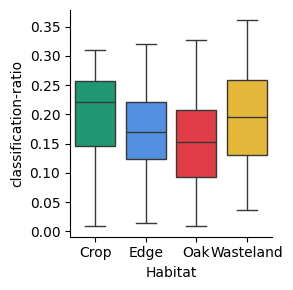

In [89]:
g = sns.catplot(
    hits_classratio, x='Habitat', y='classification-ratio', kind='box', height=3.0,
    palette=habitat_palette
)

In [90]:
hits_byrank = hits.value_counts(['rank']).reset_index()
hits_byrank['rank_position'] = hits_byrank['rank'].apply(lambda x: ['superkingdom', 'kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species'].index(x))
hits_byrank


,rank,count,rank_position
0,species,5950,7
1,family,2017,5
2,genus,1950,6
3,order,1132,4
4,class,1106,3
5,superkingdom,638,0
6,phylum,464,2
7,kingdom,313,1


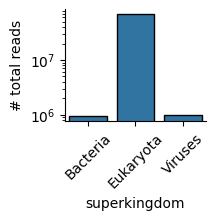

In [91]:
g = sns.catplot(
    x='superkingdom', y='count', data=hits.groupby('superkingdom')['count'].sum().reset_index().sort_values(by='superkingdom'), 
    kind='bar', height=2.0,  edgecolor='black'
)
g.set_ylabels("# total reads")
g.ax.set_yscale('log')
g.set_xticklabels(rotation=45)

In [92]:
hits.groupby('kingdom')['count'].sum().reset_index().sort_values(by='count', ascending=False)
hits['kingdom'] = hits.apply(lambda x: 'Bacteria' if x.superkingdom == 'Bacteria' else x.kingdom, axis=1)
palette_superkingdoms = {
    'Eukaryota':"#73deac",
    'Bacteria': "#8bc8e5",
    'Viruses': "#e58bb1"
}

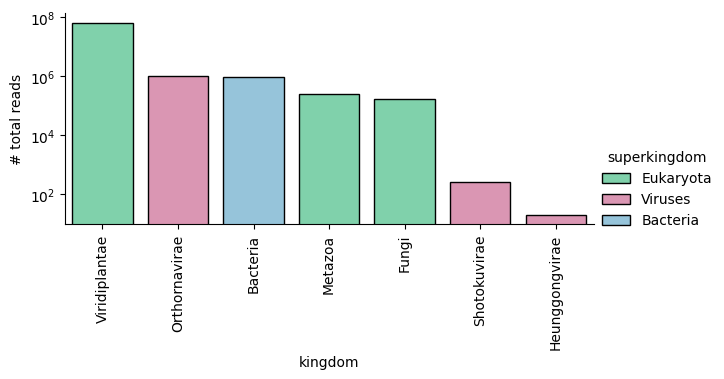

In [93]:
g = sns.catplot(
    x='kingdom', y='count', data=hits.groupby(['superkingdom', 'kingdom'])['count'].sum().reset_index().sort_values(by='count', ascending=False)[:30], 
    kind='bar', height=3.0, aspect=2.0, edgecolor='black', hue='superkingdom', palette=palette_superkingdoms
)
g.set_ylabels("# total reads")
g.set_xticklabels(rotation=90)
g.ax.set_yscale('log')

In [94]:
# hits = hits.query('kingdom != "Viridiplantae"').copy()
hits['norm_count'] = hits.groupby('library')['count'].transform(lambda x: x / x.sum())
hits.groupby('library')['norm_count'].sum()

library
PV001       1.0
PV002       1.0
PV003       1.0
PV003bgi    1.0
PV004bgi    1.0
           ... 
PV585       1.0
PV586       1.0
PV587       1.0
PV588       1.0
PV589       1.0
Name: norm_count, Length: 321, dtype: float64

In [95]:
hits_bydomain = hits.groupby(['superkingdom', 'Site_code', 'Habitat'])['count'].sum().reset_index().pivot(index=['Site_code', 'Habitat'], columns='superkingdom', values='count')
hits_bydomain

,superkingdom,Bacteria,Eukaryota,Viruses
Site_code,Habitat,,,
C1,Crop,2255.0,3259100.0,981.0
C2,Crop,4934.0,3997300.0,708.0
E1,Wasteland,49608.0,1554628.0,2066.0
E2,Wasteland,34197.0,2332278.0,109.0
E3,Wasteland,56169.0,2982032.0,13.0
E4,Wasteland,100322.0,4054862.0,212.0
H1,Crop,33532.0,620884.0,1407.0
H2,Crop,3179.0,1118771.0,4728.0
H3,Crop,1700.0,2185368.0,16713.0


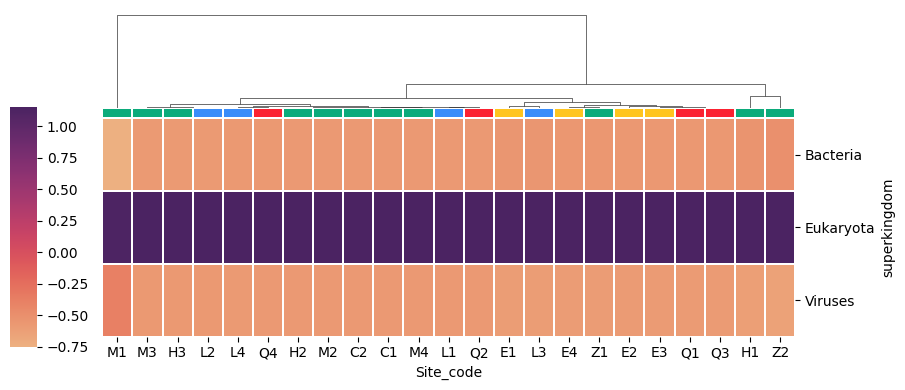

In [96]:
col_colors = [habitat_palette[item] for item in hits_bydomain.reset_index()['Habitat']]
g = sns.clustermap(
    hits_bydomain.reset_index().drop(columns='Habitat').set_index('Site_code').fillna(0.0).T, z_score=True, linewidth=0.1, 
    cmap='flare', figsize=(9, 4), row_cluster=False, cbar_pos=[0., 0.12, 0.03, 0.6], dendrogram_ratio=(0.1, 0.3),
    col_colors=col_colors
)


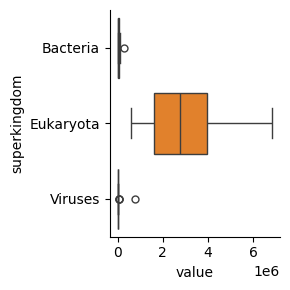

In [97]:
sns.catplot(
    data=hits_bydomain.reset_index().melt(id_vars=['Site_code', 'Habitat'], value_vars=['Bacteria', 'Eukaryota', 'Viruses']),
    y='superkingdom', x='value', hue='superkingdom', kind='box', aspect=1.0, height=3.0#, palette=palette_superkingdoms
)

In [98]:
from scipy.stats import mannwhitneyu

In [99]:

mannwhitneyu(
    hits_bydomain['Viruses'].dropna(),
    hits_bydomain['Bacteria'].dropna()
)

MannwhitneyuResult(statistic=135.0, pvalue=0.007632031806201182)

In [100]:
hits

,library,classification-ratio,taxonid,scientific_name_x,count,scientific_name_y,taxon,species,genus,family,...,rank,Site_code,Collection_code,Library_code,Location,Host_taxon,Habitat,No_extracts,Date,norm_count
0,PV001,0.122462,29722,Amaranthus tricolor,72054,Amaranthus tricolor,taxoniq.Taxon(29722),Amaranthus tricolor,Amaranthus,Amaranthaceae,...,species,M1,M1V,PV001,Aranjuez,Amaranthus sp,Crop,8,1,0.608832
1,PV001,0.122462,3398,Magnoliopsida,28778,Pentapetalae,taxoniq.Taxon(3398),<NA>,<NA>,<NA>,...,class,M1,M1V,PV001,Aranjuez,Amaranthus sp,Crop,8,1,0.243164
2,PV001,0.122462,3524,Caryophyllales,11579,Caryophyllales,taxoniq.Taxon(3524),<NA>,<NA>,<NA>,...,order,M1,M1V,PV001,Aranjuez,Amaranthus sp,Crop,8,1,0.097839
3,PV001,0.122462,2759,Eukaryota,4778,Eukaryota,taxoniq.Taxon(2759),<NA>,<NA>,<NA>,...,superkingdom,M1,M1V,PV001,Aranjuez,Amaranthus sp,Crop,8,1,0.040372
4,PV001,0.122462,3562,Spinacia oleracea,337,Spinacia oleracea,taxoniq.Taxon(3562),Spinacia oleracea,Spinacia,Chenopodiaceae,...,species,M1,M1V,PV001,Aranjuez,Amaranthus sp,Crop,8,1,0.002848
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13565,PV589,0.242175,4564,Triticum,16,Triticum,taxoniq.Taxon(4564),<NA>,Triticum,Poaceae,...,genus,H1,H1P,PV589,Villaconejos,Hordeum vulgare,Crop,8,1,0.000101
13566,PV589,0.242175,3469,Papaver somniferum,13,Papaver somniferum,taxoniq.Taxon(3469),Papaver somniferum,Papaver,Papaveraceae,...,species,H1,H1P,PV589,Villaconejos,Hordeum vulgare,Crop,8,1,0.000082
13567,PV589,0.242175,286,Pseudomonas,13,Pseudomonas,taxoniq.Taxon(286),<NA>,Pseudomonas,Pseudomonadaceae,...,genus,H1,H1P,PV589,Villaconejos,Hordeum vulgare,Crop,8,1,0.000082
13568,PV589,0.242175,135621,Pseudomonadaceae,12,Pseudomonadaceae,taxoniq.Taxon(135621),<NA>,<NA>,Pseudomonadaceae,...,family,H1,H1P,PV589,Villaconejos,Hordeum vulgare,Crop,8,1,0.000076


In [101]:
hits_bydomain = hits.groupby(['superkingdom', 'library', 'Habitat'])['count'].sum().reset_index().pivot(index=['library', 'Habitat'], columns='superkingdom', values='count')
hits_bydomain

,superkingdom,Bacteria,Eukaryota,Viruses
library,Habitat,,,
PV001,Crop,76.0,118138.0,134.0
PV002,Crop,2054.0,105733.0,89971.0
PV003,Crop,789.0,2357694.0,67418.0
PV003bgi,Crop,91.0,372064.0,458.0
PV004bgi,Crop,240.0,9431.0,NaN
...,...,...,...,...
PV585,Wasteland,1004.0,70098.0,NaN
PV586,Crop,229.0,118289.0,NaN
PV587,Crop,31923.0,54964.0,NaN


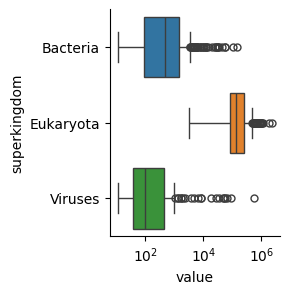

In [102]:
g = sns.catplot(
    data=hits_bydomain.reset_index().melt(id_vars=['library', 'Habitat'], value_vars=['Bacteria', 'Eukaryota', 'Viruses']),
    y='superkingdom', x='value', hue='superkingdom', kind='box', aspect=1.0, height=3.0#, palette=palette_superkingdoms
)
g.axes[0, 0].set_xscale("log")

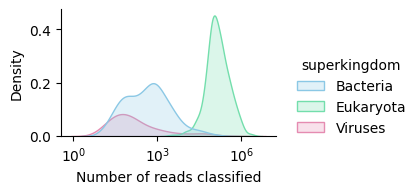

In [103]:
g = sns.displot(
    data=hits_bydomain.apply(np.log10).reset_index().melt(id_vars=['library', 'Habitat'], value_vars=['Bacteria', 'Eukaryota', 'Viruses']),
    x='value', hue='superkingdom', kind='kde', aspect=1.5, height=2.0, palette=palette_superkingdoms, fill=True
)
g.axes[0, 0].set_xticks([0, 3.0, 6.0])
g.set_xticklabels(['$10^{0}$', '$10^{3}$', '$10^{6}$'])
g.set_xlabels("Number of reads classified")
g.savefig("figures/displot.kraken2-profiling.svg")


In [28]:
hits_bydomain.apply(np.log10).reset_index().melt(id_vars=['library', 'Habitat'], value_vars=['Bacteria', 'Eukaryota', 'Viruses'])

,library,Habitat,superkingdom,value
0,PV001,Crop,Bacteria,1.880814
1,PV002,Crop,Bacteria,3.312600
2,PV003,Crop,Bacteria,2.897077
3,PV003bgi,Crop,Bacteria,1.959041
4,PV004bgi,Crop,Bacteria,2.380211
...,...,...,...,...
958,PV585,Wasteland,Viruses,NaN
959,PV586,Crop,Viruses,NaN
960,PV587,Crop,Viruses,NaN
961,PV588,Crop,Viruses,3.115611


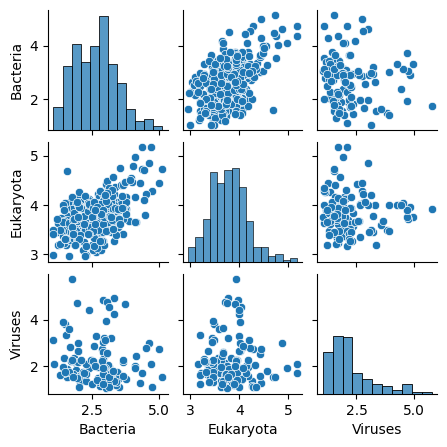

In [38]:
sns.pairplot(hits_bydomain.apply(np.log10), aspect=1.0,height=1.5)

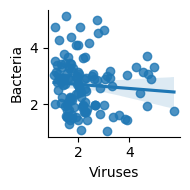

In [39]:
sns.lmplot(
    data=hits_bydomain.apply(np.log10),
    x='Viruses',
    y='Bacteria', height=2.0
)

In [40]:
from scipy.stats import linregress

In [41]:
linregress(
    hits_bydomain.apply(np.log10).dropna()['Viruses'],
    hits_bydomain.apply(np.log10).dropna()['Bacteria']
)

LinregressResult(slope=-0.07200762661744453, intercept=2.843380044262135, rvalue=-0.0785796131625051, pvalue=0.3956204356361027, stderr=0.084456035568718, intercept_stderr=0.20518865010984239)

In [42]:
metadata = pd.read_csv("output/metadata.site-library.csv", sep=";")
bacteria_hits = pd.read_csv("output/hits.bacteria.csv", sep=";").query("is_pab==True")
bacteria_hits = pd.merge(metadata, bacteria_hits, on='library', how='left').dropna(subset='taxid')
bacteria_hits['taxid'] = bacteria_hits['taxid'].astype(int)
bacteria_hits

,site,library,habitat,n_extracts,host_taxon,taxid,scientific_name,gtdb_genome_representative,is_pab,pab_type
1,C1,PV535,Crop,17,Brassica oleracea,1563157,Pseudomonas endophytica,RS GCF 001411475.1,True,pab_unknown
2,C1,PV535,Crop,17,Brassica oleracea,1270,Micrococcus luteus,RS GCF 000023205.1,True,pab_unknown
5,C1,PV544,Crop,4,Sisymbrium runcinatum,1735685,Sphingomonas sp. Leaf20,RS GCF 001421535.1,True,pab_unknown
6,C1,PV544,Crop,4,Sisymbrium runcinatum,1828,Rhodococcoides fascians,RS GCF 002259415.1,True,pab_unknown
7,C1,PV544,Crop,4,Sisymbrium runcinatum,1735683,Sphingomonas sp. Leaf17,RS GCF 001421505.1,True,pab_unknown
...,...,...,...,...,...,...,...,...,...,...
636,Z2,PV527,Crop,4,Convolvulus arvensis,1770058,Devosia elaeis,RS GCF 001650025.1,True,pab_unknown
637,Z2,PV529,Crop,1,Picris echioides,47880,Pseudomonas fulva,RS GCF 002021815.1,True,pab_unknown
638,Z2,PV529,Crop,1,Picris echioides,1220495,Pseudomonas punonensis,RS GCF 900142655.1,True,pab_unknown
639,Z2,PV529,Crop,1,Picris echioides,289370,Pseudomonas argentinensis,RS GCF 001839655.2,True,pab_unknown


In [55]:
bacteria_hits_by_library = bacteria_hits.query('is_pab == True').value_counts(['library', 'habitat', 'site']).reset_index()
bacteria_hits_by_library

,library,habitat,site,count
0,PV215,Edge,L3,43
1,PV078,Wasteland,E4,38
2,PV527,Crop,Z2,35
3,PV212,Edge,L3,14
4,PV525,Crop,Z1,10
...,...,...,...,...
131,PV083,Oak,Q1,1
132,PV075,Wasteland,E2,1
133,PV174,Edge,L2,1
134,PV069,Wasteland,E1,1


In [56]:
u = hits_bydomain.reset_index().melt(id_vars=['library', 'Habitat'], value_vars=['Bacteria', 'Eukaryota', 'Viruses'])

In [57]:
m = pd.merge(
    bacteria_hits_by_library[['library', 'count']].rename(columns={'count': 'motus-hits'}), 
    u[['library', 'superkingdom', 'value']].query('superkingdom == "Bacteria"').rename(columns={'value':'kraken2-reads'}), on='library')
m

,library,motus-hits,superkingdom,kraken2-reads
0,PV215,43,Bacteria,139465.0
1,PV078,38,Bacteria,57453.0
2,PV527,35,Bacteria,101319.0
3,PV212,14,Bacteria,42160.0
4,PV525,10,Bacteria,34576.0
...,...,...,...,...
130,PV083,1,Bacteria,525.0
131,PV075,1,Bacteria,1066.0
132,PV174,1,Bacteria,2161.0
133,PV069,1,Bacteria,186.0


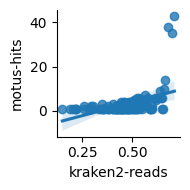

In [62]:
m['kraken2-reads'] = m['kraken2-reads'].apply(np.log10)
g = sns.lmplot(data=m, x='kraken2-reads', y='motus-hits', height=2.0)


In [61]:
linregress(
    m.dropna()['kraken2-reads'], m.dropna()['motus-hits'].dropna()
)

LinregressResult(slope=4.250416019067262, intercept=-9.86337108227556, rvalue=0.5453595424862646, pvalue=9.524469405373094e-12, stderr=0.5686045970921371, intercept_stderr=1.8062324479083811)

In [64]:
# metadata = pd.read_csv("output/metadata.site-library.csv", sep=";")
virus_hits = pd.read_csv("output/hits.virus.csv", sep=";")#.query("is_pab==True")
virus_hits = pd.merge(metadata, virus_hits, on='library', how='left').dropna(subset='taxid')
virus_hits['taxid'] = virus_hits['taxid'].astype(int)
virus_hits_by_library = virus_hits.value_counts(['library', 'habitat', 'site']).reset_index()
virus_hits_by_library

,library,habitat,site,count
0,PV212,Edge,L3,25
1,PV172,Edge,L2,24
2,PV143,Edge,L3,22
3,PV156,Edge,L4,16
4,PV224,Edge,L3,16
...,...,...,...,...
280,PV369,Wasteland,E3,1
281,PV058,Wasteland,E4,1
282,PV050,Crop,Z1,1
283,PV421,Oak,Q1,1


In [65]:
m = pd.merge(
    virus_hits_by_library[['library', 'count']].rename(columns={'count': 'motus-hits'}), 
    u[['library', 'superkingdom', 'value']].query('superkingdom == "Viruses"').rename(columns={'value':'kraken2-reads'}), on='library')
m

,library,motus-hits,superkingdom,kraken2-reads
0,PV212,25,Viruses,980.0
1,PV172,24,Viruses,146.0
2,PV143,22,Viruses,6642.0
3,PV156,16,Viruses,1680.0
4,PV224,16,Viruses,83.0
...,...,...,...,...
278,PV369,1,Viruses,NaN
279,PV058,1,Viruses,NaN
280,PV050,1,Viruses,NaN
281,PV421,1,Viruses,NaN


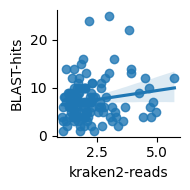

In [66]:
m['kraken2-reads'] = m['kraken2-reads'].apply(np.log10)
g = sns.lmplot(data=m, x='kraken2-reads', y='motus-hits', height=2.0)
g.set_ylabels("BLAST-hits")


In [67]:
linregress(
    m.dropna()['kraken2-reads'], m.dropna()['motus-hits'].dropna()
)

LinregressResult(slope=0.7437062381928733, intercept=5.693265266379669, rvalue=0.17018610694080116, pvalue=0.06200585008015832, stderr=0.394749564484826, intercept_stderr=0.9622135989851351)